# Cross-Dataset Generalization of Deep Learning Models for Diabetic Retinopathy Grading

**Dissertation notebook** — trains a baseline EfficientNetB0 classifier on APTOS 2019 and
evaluates zero-shot generalization on Messidor-2 and IDRiD.

**Contents**
1. Setup & Imports
2. Data Loading
3. Label & Shape Verification
4. Data Cleaning — Deduplication
5. Exploratory Data Analysis
6. Train / Val / Test Split (APTOS)
7. Image Loading into Arrays
8. Class Weights
9. Baseline Model — EfficientNetB0
10. Training Curves
11. External Dataset Preparation (Messidor-2, IDRiD)
12. Evaluation — RQ1 (APTOS, in-distribution)
13. Evaluation — RQ2 & RQ4 (Cross-dataset generalization)
14. Results Summary
    
    14.1. Bootstrap Confidence Interval
    
    14.2. Ablation: Class Weighting vs No Class Weighting

    14.3. Ablation: Frozen vs Fine-Tuned Layers

    14.4. Multi-seed Stability Analysis
    
15. Mitigation Technique — Test-Time Augmentation (RQ3)

    15.1. Repeated TTA Evaluation for Uncertainty
    
17. Appendix — Models Not Used

This notebook implements the full experimental pipeline for the dissertation:
training an EfficientNetB0 baseline on APTOS 2019, evaluating zero-shot on
Messidor-2 and IDRiD, testing a class-weighting and a frozen-layers ablation,
running a 6-seed stability analysis, and evaluating Test-Time Augmentation (TTA)
as a lightweight mitigation technique.

**To reproduce:** run all cells sequentially from top to bottom. Random seeds
are fixed (Section 1), though residual GPU-level nondeterminism means exact
values may vary slightly between runs — see Section 14.2 for the documented range.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import hashlib
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tqdm import tqdm
import time
import sklearn
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB7
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, cohen_kappa_score,confusion_matrix, recall_score, f1_score, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


warnings.filterwarnings("ignore")
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
print(f"TensorFlow: {tf.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.20.0
scikit-learn: 1.6.1
NumPy: 2.0.2
Pandas: 2.3.3


In [3]:
tf.random.set_seed(42)
np.random.seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
tf.config.experimental.enable_op_determinism()

## 2. Data Loading

In [4]:
apt_df=pd.read_csv("/kaggle/input/competitions/aptos2019-blindness-detection/train.csv")
ms_df=pd.read_csv("/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv", usecols=['id_code', 'diagnosis'])
idr_df=pd.read_csv("/kaggle/input/datasets/mariaherrerot/idrid-dataset/idrid_labels.csv", usecols=['id_code', 'diagnosis'])

In [5]:
apt_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [6]:
ms_df.head()

,id_code,diagnosis
0,20051020_43808_0100_PP.png,0
1,20051020_43832_0100_PP.png,1
2,20051020_43882_0100_PP.png,1
3,20051020_43906_0100_PP.png,2
4,20051020_44261_0100_PP.png,0


In [7]:
idr_df.head()

,id_code,diagnosis
0,IDRiD_001,3
1,IDRiD_002,3
2,IDRiD_003,2
3,IDRiD_004,3
4,IDRiD_005,4


## 3. Label & Shape Verification

Confirms all three datasets use the same 0–4 ICDR-style severity scale, so no label harmonisation is required.

In [8]:
print("APTOS-2019 target feature labels:",np.sort(apt_df.diagnosis.unique()))
print("Messidor-2 target feature labels:",np.sort(ms_df.diagnosis.unique()))
print("IDRid: DR-Grading target feature labels:",np.sort(idr_df.diagnosis.unique()))

APTOS-2019 target feature labels: [0 1 2 3 4]
Messidor-2 target feature labels: [0 1 2 3 4]
IDRid: DR-Grading target feature labels: [0 1 2 3 4]


In [9]:
print("APTOS-2019 dataset shape:", apt_df.shape)
print("Messidor-2 dataset shape:", ms_df.shape)
print("IDRid: DR-Grading dataset shape:", idr_df.shape)

APTOS-2019 dataset shape: (3662, 2)
Messidor-2 dataset shape: (1744, 2)
IDRid: DR-Grading dataset shape: (455, 2)


## 4. Data Cleaning — Deduplication

APTOS 2019 provides no patient/eye identifier, so patient-level splitting (as recommended in the
literature) is not verifiable from the available metadata. As a proxy safeguard, images are
deduplicated by MD5 content hash before splitting, to prevent the same photo appearing in both
train and test partitions.

In [10]:
apt_df.duplicated().sum()

np.int64(0)

In [11]:
img_dir = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'

hashes = {}
duplicate_ids = []

for filename in apt_df['id_code']:
    filepath = os.path.join(img_dir, f"{filename}.png")
    with open(filepath, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h in hashes:
        duplicate_ids.append(filename)
    else:
        hashes[h] = filename

print(f"Duplicate images found in APTOS-2019 Dataset (by actual content): {len(duplicate_ids)}")

Duplicate images found in APTOS-2019 Dataset (by actual content): 128


In [12]:
# Remove duplicates, keeping the first occurrence of each
clean_df = apt_df[~apt_df['id_code'].isin(duplicate_ids)].reset_index(drop=True)
print(f"Original: {len(apt_df)}  ->  After dedup: {len(clean_df)}")

Original: 3662  ->  After dedup: 3534


## 5. Exploratory Data Analysis

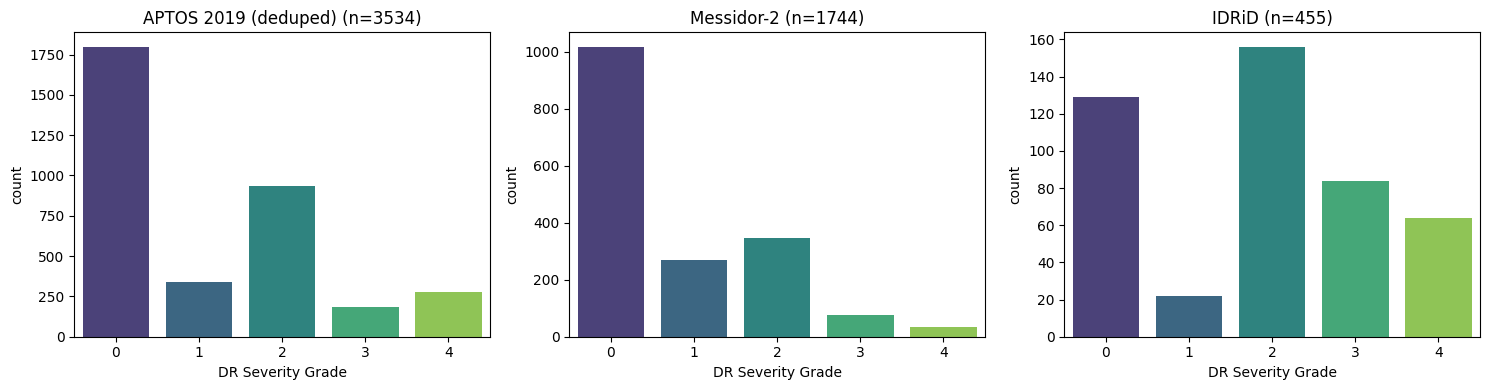

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, name in zip(axes, [clean_df, ms_df, idr_df], ['APTOS 2019 (deduped)', 'Messidor-2', 'IDRiD']):
    sns.countplot(x='diagnosis', data=df, ax=ax, palette='viridis')
    ax.set_title(f'{name} (n={len(df)})')
    ax.set_xlabel('DR Severity Grade')
plt.tight_layout()
# plt.savefig('/kaggle/working/class_distributions.png', dpi=150)
plt.show()

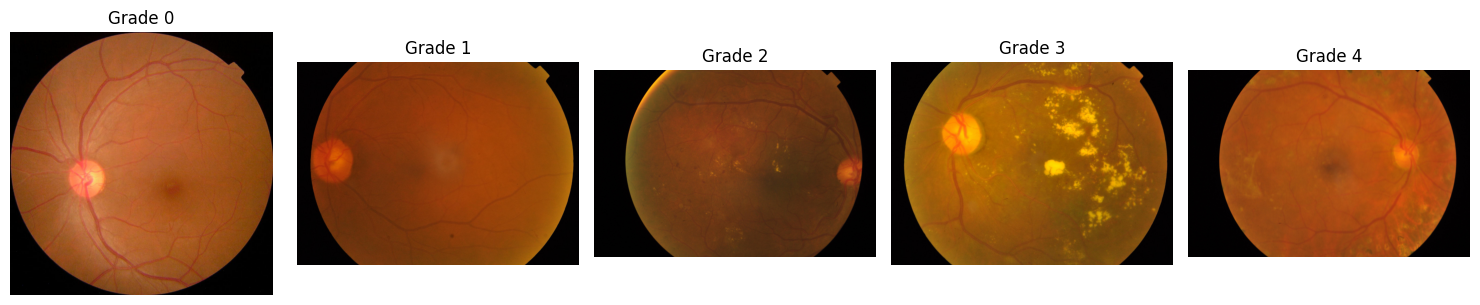

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for grade in range(5):
    sample = clean_df[clean_df['diagnosis'] == grade].iloc[0]
    img = Image.open(f"{img_dir}/{sample['id_code']}.png")
    axes[grade].imshow(img)
    axes[grade].set_title(f'Grade {grade}')
    axes[grade].axis('off')
plt.tight_layout()
# plt.savefig('/kaggle/working/sample_images_by_grade.png', dpi=150)
plt.show()

## 6. Train / Val / Test Split (APTOS)

Stratified 70/15/15 split on the deduplicated pool, preserving class proportions.

In [15]:
# First split off test (15%)
train_val_df, test_df = train_test_split(
    clean_df, test_size=0.15, stratify=clean_df['diagnosis'], random_state=42
)

# Then split remaining into train (70% of total) / val (15% of total)
train_df_final, val_df = train_test_split(
    train_val_df, test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765
    stratify=train_val_df['diagnosis'], random_state=42
)

print(f"Train: {len(train_df_final)}, Val: {len(val_df)}, Test: {len(test_df)}")
for name, df in [('Train', train_df_final), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name} class distribution:")
    print(df['diagnosis'].value_counts(normalize=True).sort_index().round(3))

train_df_final.to_csv('/kaggle/working/aptos_train.csv', index=False)
val_df.to_csv('/kaggle/working/aptos_val.csv', index=False)
test_df.to_csv('/kaggle/working/aptos_test.csv', index=False)

Train: 2472, Val: 531, Test: 531

Train class distribution:
diagnosis
0    0.509
1    0.097
2    0.264
3    0.051
4    0.079
Name: proportion, dtype: float64

Val class distribution:
diagnosis
0    0.508
1    0.096
2    0.266
3    0.051
4    0.079
Name: proportion, dtype: float64

Test class distribution:
diagnosis
0    0.508
1    0.096
2    0.264
3    0.053
4    0.079
Name: proportion, dtype: float64


## 7. Image Loading into Arrays

In [16]:
IMG_SIZE = 224
IMG_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'

train_df_final = pd.read_csv('/kaggle/working/aptos_train.csv')
val_df = pd.read_csv('/kaggle/working/aptos_val.csv')
test_df = pd.read_csv('/kaggle/working/aptos_test.csv')

# General image loading to array function
def load_images_to_array(df, img_dir, img_format, img_size):
    images = np.zeros((len(df), img_size, img_size, 3), dtype=np.float32)
    labels = df['diagnosis'].astype(int).values
    for i, fname in enumerate(tqdm(df['id_code'])):
        img = Image.open(f"{img_dir}/{fname}.{img_format}").convert('RGB').resize((img_size, img_size))
        images[i] = np.array(img) / 255.0
    return images, labels


# Specific image loading to array function for Messidor-2 dataset
def load_images_to_array2(df, img_dir, img_size):
    images = np.zeros((len(df), img_size, img_size, 3), dtype=np.float32)
    labels = df['diagnosis'].astype(int).values
    for i, fname in enumerate(tqdm(df['id_code'])):
        img = Image.open(f"{img_dir}/{fname}").convert('RGB').resize((img_size, img_size))
        images[i] = np.array(img) / 255.0
    return images, labels

start = time.time()
X_train, y_train = load_images_to_array(train_df_final, IMG_DIR, 'png',IMG_SIZE)
print(f"Train images loaded in {time.time()-start:.1f}s, shape: {X_train.shape}")

start = time.time()
X_val, y_val = load_images_to_array(val_df, IMG_DIR, 'png', IMG_SIZE)
X_test, y_test = load_images_to_array(test_df, IMG_DIR, 'png', IMG_SIZE)
print(f"Val/test images loaded in {time.time()-start:.1f}s")

100%|██████████| 2472/2472 [04:59<00:00,  8.26it/s]


Train images loaded in 299.4s, shape: (2472, 224, 224, 3)


100%|██████████| 531/531 [01:04<00:00,  8.21it/s]

Val/test images loaded in 127.7s


In [17]:
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (2472, 224, 224, 3) y_train: (2472,)
X_val: (531, 224, 224, 3) y_val: (531,)
X_test: (531, 224, 224, 3) y_test: (531,)


## 8. Class Weights

Compensates for APTOS's class imbalance (~51% class 0 vs ~5% class 3) during training.

In [18]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.39300476947535773), 1: np.float64(2.0686192468619247), 2: np.float64(0.7571209800918837), 3: np.float64(3.8929133858267715), 4: np.float64(2.5353846153846153)}


## 9. Baseline Model — EfficientNetB0

EfficientNetB0 chosen as the sole baseline architecture per the approved dissertation scope
(single-model pipeline, protecting time for cross-dataset evaluation and the mitigation technique).

**Note on preprocessing:** Keras's `EfficientNetB0` includes normalisation as part of the model
itself and expects raw pixel values in `[0, 255]`. Since `X_train`/`X_val`/`X_test` were loaded as
`[0, 1]` (divided by 255 above for consistency with the other model variants in the Appendix), they
are multiplied back by 255 at `.fit()` / `.predict()` time below. This must be applied consistently
at both training and inference time — forgetting it at inference is what caused the invalid,
all-class-0 predictions in an earlier notebook version.

In [19]:
NUM_CLASSES=5

enb0_base_model=EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
enb0_base_model.trainable=True

for layer in enb0_base_model.layers[:-10]:  # keep most of the base frozen, unfreeze last ~10 layers
    layer.trainable = False

x = GlobalAveragePooling2D()(enb0_base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
enb0_model = Model(inputs=enb0_base_model.input, outputs=output)

enb0_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])



enb0_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_enb0_cnn.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

enb0_history = enb0_model.fit(
    X_train*255., y_train,
    validation_data=(X_val*255., y_val),
    batch_size=64,
    epochs=40,                    # early stopping will cut this short automatically
    class_weight=class_weight_dict,
    callbacks=enb0_callbacks
)

I0000 00:00:1788737985.913072      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788737985.918929      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


2026-09-06 23:39:54.549740: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1788738004.775478      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5138 - loss: 1.2883

2026-09-06 23:40:17.620914: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 321ms/step - accuracy: 0.6100 - loss: 1.1537 - val_accuracy: 0.7514 - val_loss: 0.6406 - learning_rate: 0.0010
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.7662 - loss: 0.8014 - val_accuracy: 0.7495 - val_loss: 0.6145 - learning_rate: 0.0010
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.8022 - loss: 0.6740 - val_accuracy: 0.8060 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.8329 - loss: 0.5813 - val_accuracy: 0.8154 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.8499 - loss: 0.4852 - val_accuracy: 0.7834 - val_loss: 0.6089 - learning_rate: 0.0010
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.8584 - loss: 0.4325 - val_accuracy: 0.7853 - val_loss: 0.6359 - learning_rate: 0.0010
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.8839 - loss: 0.3984 - val_accura

## 10. Training Curves

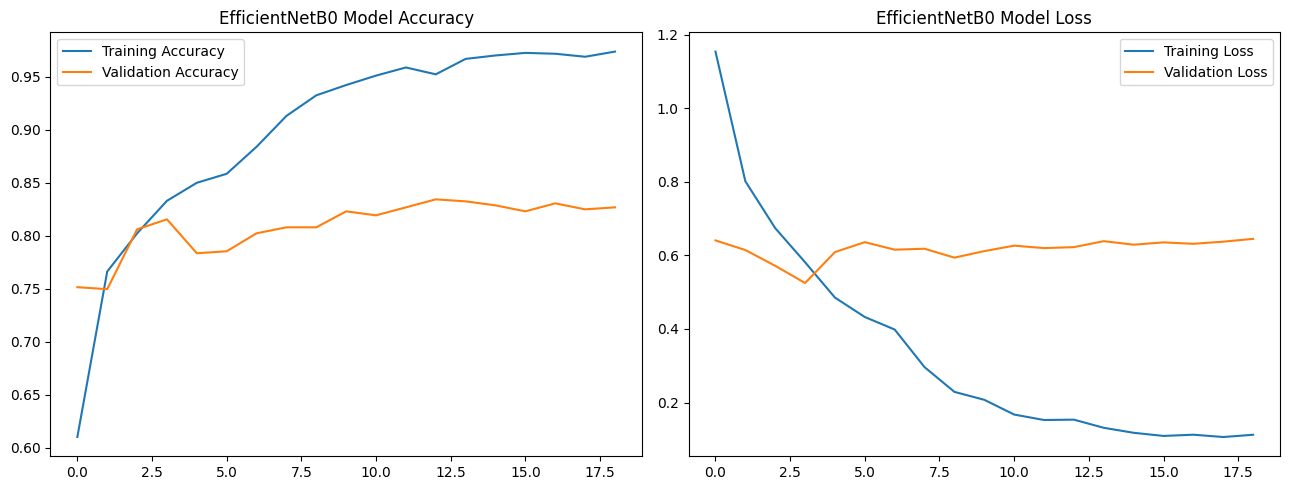

In [20]:
enb0_epoch=[epoch for epoch in range(len(enb0_history.history['accuracy']))]

fig,ax=plt.subplots(1,2, figsize=(13,5))

# EfficientNetB0 History
sns.lineplot(x=enb0_epoch, y=enb0_history.history['accuracy'], ax=ax[0], label='Training Accuracy')
sns.lineplot(x=enb0_epoch, y=enb0_history.history['val_accuracy'], ax=ax[0], label='Validation Accuracy')
ax[0].set_title('EfficientNetB0 Model Accuracy')

sns.lineplot(x=enb0_epoch, y=enb0_history.history['loss'], ax=ax[1], label='Training Loss')
sns.lineplot(x=enb0_epoch, y=enb0_history.history['val_loss'], ax=ax[1], label='Validation Loss')
ax[1].set_title('EfficientNetB0 Model Loss')


plt.tight_layout()
plt.legend()
plt.show()

## 11. External Dataset Preparation (Messidor-2, IDRiD)

Both datasets are used purely as external, zero-shot test sets — no fine-tuning, no internal
train/val/test split of their own. They are deduplicated for consistency with the APTOS
methodology, though this only matters if either is ever reused for training in future work.

In [21]:
# IDRiD: Diabetic Retinopathy - Grading
idr_img_dir = '/kaggle/input/datasets/mariaherrerot/idrid-dataset/Imagenes/Imagenes'

idr_hashes = {}
idr_duplicate_ids = []


for filename in idr_df['id_code']:
    idr_filepath = os.path.join(idr_img_dir, f"{filename}.jpg")
    with open(idr_filepath, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h in idr_hashes:
        idr_duplicate_ids.append(filename)
    else:
        idr_hashes[h] = filename

print(f"Duplicate images found (by actual content): {len(idr_duplicate_ids)}")


# Messidor-2
ms_img_dir = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'

ms_hashes = {}
ms_duplicate_ids = []


for filename in ms_df['id_code']:
    ms_filepath = os.path.join(ms_img_dir, f"{filename}")
    with open(ms_filepath, 'rb') as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h in ms_hashes:
        ms_duplicate_ids.append(filename)
    else:
        ms_hashes[h] = filename

print(f"Duplicate images found (by actual content): {len(ms_duplicate_ids)}")

Duplicate images found (by actual content): 5
Duplicate images found (by actual content): 4


In [22]:
# IDRiD dataset: Remove duplicates, keeping the first occurrence of each
idr_clean_df = idr_df[~idr_df['id_code'].isin(idr_duplicate_ids)].reset_index(drop=True)
print(f"Original: {len(idr_df)}  ->  After dedup: {len(idr_clean_df)}")

# Messidor dataset: Remove duplicates, keeping the first occurrence of each
ms_clean_df = ms_df[~ms_df['id_code'].isin(ms_duplicate_ids)].reset_index(drop=True)
print(f"Original: {len(ms_df)}  ->  After dedup: {len(ms_clean_df)}")


idr_clean_df.to_csv('/kaggle/working/IDRiD_test.csv', index=False)
ms_clean_df.to_csv("/kaggle/working/Messidor_test.csv", index=False)

Original: 455  ->  After dedup: 450
Original: 1744  ->  After dedup: 1740


In [23]:
# Reload the best checkpointed model from disk (rather than relying on the in-memory object)
# — more reproducible, since it confirms the saved artifact is what actually gets evaluated.
enb0_model_saved=load_model('/kaggle/working/best_enb0_cnn.keras')

In [24]:
idr_clean_df=pd.read_csv('/kaggle/working/IDRiD_test.csv')
ms_clean_df=pd.read_csv('/kaggle/working/Messidor_test.csv')

IDR_IMG_DIR='/kaggle/input/datasets/mariaherrerot/idrid-dataset/Imagenes/Imagenes'
MS_IMG_DIR='/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'

idr_X_test, idr_y_test = load_images_to_array(idr_clean_df, IDR_IMG_DIR,'jpg', IMG_SIZE)
ms_X_test, ms_y_test = load_images_to_array2(ms_clean_df, MS_IMG_DIR, IMG_SIZE)

100%|██████████| 1740/1740 [00:16<00:00, 106.17it/s]


## 12. Evaluation — RQ1 (APTOS, in-distribution)

*RQ1: How does a baseline deep learning model perform on the APTOS 2019 dataset under standard
evaluation?*

Establishes the baseline against which cross-dataset performance (Section 13) is compared.
Reports precision, recall, F1 per class, and quadratic weighted kappa — the same metric used
by the original APTOS competition, for comparability with published results.

In [25]:
aptos_pred_probs=enb0_model_saved.predict(X_test*255.)
aptos_pred=np.argmax(aptos_pred_probs, axis=1)

print(classification_report(y_test, aptos_pred, digits=3))
print("APTOS Quadratic Weighted kappa score:", cohen_kappa_score(y_test, aptos_pred, weights='quadratic'))

2026-09-06 23:44:53.725623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step
              precision    recall  f1-score   support

           0      0.981     0.967     0.974       270
           1      0.551     0.529     0.540        51
           2      0.712     0.779     0.744       140
           3      0.429     0.429     0.429        28
           4      0.657     0.548     0.597        42

    accuracy                          0.814       531
   macro avg      0.666     0.650     0.657       531
weighted avg      0.814     0.814     0.813       531

APTOS Quadratic Weighted kappa score: 0.8894390620018349


## 13. Evaluation — RQ2 & RQ4 (Cross-dataset generalization)

*RQ2: How does performance change when evaluated on Messidor-2 and IDRiD without fine-tuning?*

*RQ4: Which severity classes are most affected by the distribution shift?*

The baseline model from Section 12 is applied directly to Messidor-2 and IDRiD with no
retraining or fine-tuning — a zero-shot test of generalization to unseen clinics, devices, and
grading protocols. Per-class metrics (not just accuracy) are used throughout to answer RQ4.

In [26]:
idr_pred_probs = enb0_model_saved.predict(idr_X_test * 255.)
idr_pred = np.argmax(idr_pred_probs, axis=1)

ms_pred_probs = enb0_model_saved.predict(ms_X_test * 255.)
ms_pred = np.argmax(ms_pred_probs, axis=1)

print("=== IDRiD ===")
print(classification_report(idr_y_test, idr_pred, digits=3))
print("IDRiD Quadratic Weighted Kappa:", cohen_kappa_score(idr_y_test, idr_pred, weights='quadratic'))

print("\n=== Messidor-2 ===")
print(classification_report(ms_y_test, ms_pred, digits=3))
print("Messidor-2 Quadratic Weighted Kappa:", cohen_kappa_score(ms_y_test, ms_pred, weights='quadratic'))

 1/15 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step

2026-09-06 23:44:59.924904: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
 1/55 ━━━━━━━━━━━━━━━━━━━━ 50s 935ms/step

2026-09-06 23:45:04.936324: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step
=== IDRiD ===
              precision    recall  f1-score   support

           0      0.816     0.651     0.724       129
           1      0.100     0.400     0.160        20
           2      0.556     0.682     0.612       154
           3      0.375     0.072     0.121        83
           4      0.532     0.516     0.524        64

    accuracy                          0.524       450
   macro avg      0.476     0.464     0.428       450
weighted avg      0.573     0.524     0.521       450

IDRiD Quadratic Weighted Kappa: 0.7625233417228221

=== Messidor-2 ===
              precision    recall  f1-score   support

           0      0.637     0.958     0.765      1017
           1      0.045     0.004     0.007       268
           2      0.355     0.159     0.220       345
           3      0.600     0.040     0.075        75
           4      0.429     0.343     0.381        35

    accuracy                          0.601      1740
   mac

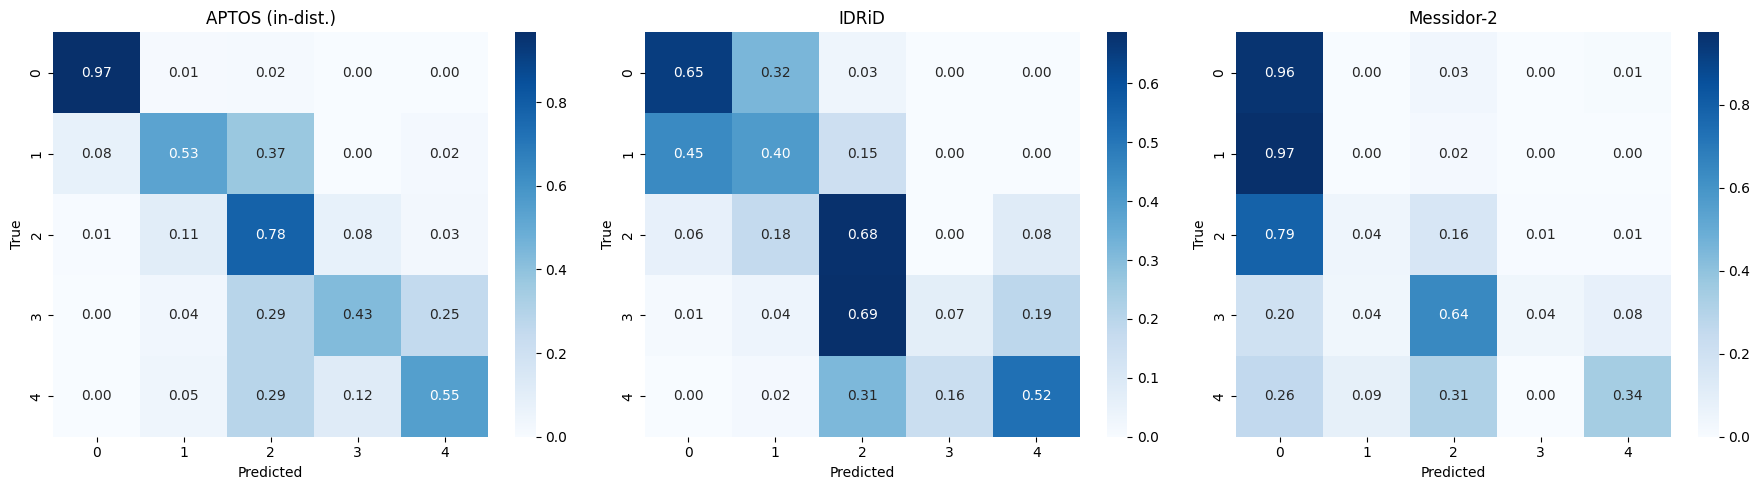

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [
    ('APTOS (in-dist.)', y_test, aptos_pred),
    ('IDRiD', idr_y_test, idr_pred),
    ('Messidor-2', ms_y_test, ms_pred),
]
for ax, (name, y_true, y_pred) in zip(axes, datasets):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=range(5), yticklabels=range(5))
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()

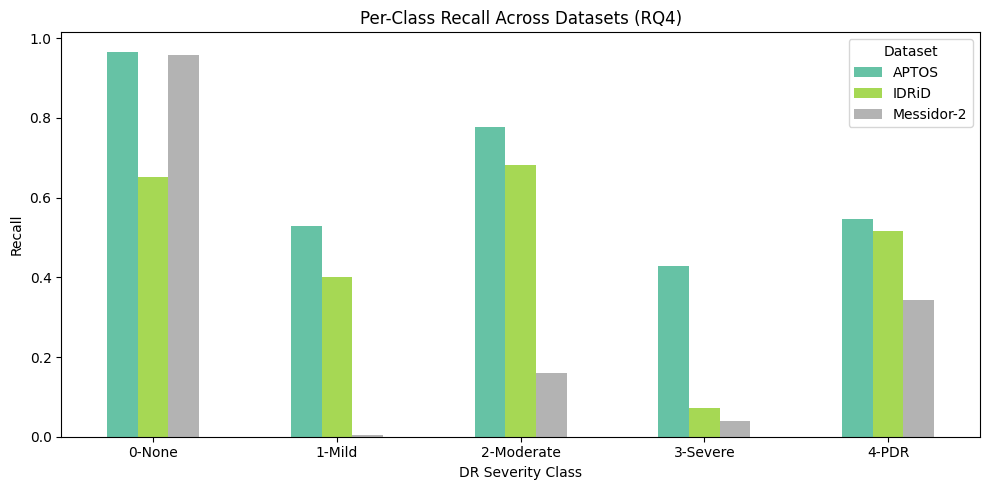

,APTOS,IDRiD,Messidor-2
0-None,0.967,0.651,0.958
1-Mild,0.529,0.400,0.004
2-Moderate,0.779,0.682,0.159
3-Severe,0.429,0.072,0.040
4-PDR,0.548,0.516,0.343


In [28]:
recall_data = pd.DataFrame({
    'APTOS': recall_score(y_test, aptos_pred, average=None, labels=range(5)),
    'IDRiD': recall_score(idr_y_test, idr_pred, average=None, labels=range(5)),
    'Messidor-2': recall_score(ms_y_test, ms_pred, average=None, labels=range(5)),
}, index=['0-None', '1-Mild', '2-Moderate', '3-Severe', '4-PDR'])

recall_data.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Per-Class Recall Across Datasets (RQ4)')
plt.ylabel('Recall')
plt.xlabel('DR Severity Class')
plt.legend(title='Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

recall_data.round(3)

## 14. Results Summary

Consolidates RQ1/RQ2/RQ4 findings into a single comparison table (point estimates), followed
by 95% bootstrapped confidence intervals (Section 14.1) to quantify the uncertainty in each
estimate, particularly for the low-support Severe NPDR class.

In [29]:
summary = pd.DataFrame({
    'Dataset': ['APTOS (in-distribution)', 'IDRiD (external)', 'Messidor-2 (external)'],
    'Accuracy': [
        accuracy_score(y_test, aptos_pred),
        accuracy_score(idr_y_test, idr_pred),
        accuracy_score(ms_y_test, ms_pred),
    ],
    'Macro F1': [
        f1_score(y_test, aptos_pred, average='macro'),
        f1_score(idr_y_test, idr_pred, average='macro'),
        f1_score(ms_y_test, ms_pred, average='macro'),
    ],
    'QW Kappa': [
        cohen_kappa_score(y_test, aptos_pred, weights='quadratic'),
        cohen_kappa_score(idr_y_test, idr_pred, weights='quadratic'),
        cohen_kappa_score(ms_y_test, ms_pred, weights='quadratic'),
    ],
    'Class 3 (Severe) Recall': [
        recall_score(y_test, aptos_pred, average=None, labels=range(5))[3],
        recall_score(idr_y_test, idr_pred, average=None, labels=range(5))[3],
        recall_score(ms_y_test, ms_pred, average=None, labels=range(5))[3],
    ],
})
summary = summary.round(3)
summary.to_csv('/kaggle/working/results_summary.csv', index=False)
summary

,Dataset,Accuracy,Macro F1,QW Kappa,Class 3 (Severe) Recall
0,APTOS (in-distribution),0.814,0.657,0.889,0.429
1,IDRiD (external),0.524,0.428,0.763,0.072
2,Messidor-2 (external),0.601,0.290,0.380,0.040


### 14.1. Bootstrapped Confidence Intervals

Point estimates alone can be misleading for classes with few test samples (e.g. n=28 for
Severe NPDR). 1,000 bootstrap resamples give a 95% CI for kappa, macro F1, and Class 3
recall on each dataset.

In [30]:
def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95, **metric_kwargs):
    """
    Computes a bootstrapped confidence interval for a given sklearn-style metric
    by resampling (y_true, y_pred) pairs with replacement.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)
    scores = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        score = metric_fn(y_true[idx], y_pred[idx], **metric_kwargs)
        scores.append(score)

    lower = np.percentile(scores, (100 - ci) / 2)
    upper = np.percentile(scores, 100 - (100 - ci) / 2)
    return np.mean(scores), lower, upper

In [31]:
from sklearn.metrics import cohen_kappa_score, f1_score, recall_score

results = []
datasets = [
    ('APTOS (in-dist.)', y_test, aptos_pred),
    ('IDRiD', idr_y_test, idr_pred),
    ('Messidor-2', ms_y_test, ms_pred),
]

for name, y_true, y_pred in datasets:
    kappa_mean, kappa_lo, kappa_hi = bootstrap_metric_ci(
        y_true, y_pred, cohen_kappa_score, weights='quadratic')
    f1_mean, f1_lo, f1_hi = bootstrap_metric_ci(
        y_true, y_pred, f1_score, average='macro')
    recall3_mean, recall3_lo, recall3_hi = bootstrap_metric_ci(
        y_true, y_pred, lambda yt, yp: recall_score(yt, yp, average=None, labels=range(5))[3])

    results.append({
        'Dataset': name,
        'QW Kappa': f"{kappa_mean:.3f} [{kappa_lo:.3f}, {kappa_hi:.3f}]",
        'Macro F1': f"{f1_mean:.3f} [{f1_lo:.3f}, {f1_hi:.3f}]",
        'Class 3 Recall': f"{recall3_mean:.3f} [{recall3_lo:.3f}, {recall3_hi:.3f}]",
    })

ci_summary = pd.DataFrame(results)
ci_summary.to_csv('/kaggle/working/results_summary_with_ci.csv', index=False)
ci_summary

,Dataset,QW Kappa,Macro F1,Class 3 Recall
0,APTOS (in-dist.),"0.890 [0.862, 0.917]","0.655 [0.599, 0.714]","0.427 [0.242, 0.615]"
1,IDRiD,"0.762 [0.724, 0.799]","0.427 [0.384, 0.470]","0.070 [0.023, 0.128]"
2,Messidor-2,"0.380 [0.326, 0.431]","0.290 [0.253, 0.328]","0.041 [0.000, 0.092]"


### 14.2. Ablation: Class Weighting vs. No Class Weighting

To strengthen the modelling contribution beyond a single baseline, this ablation
retrains the identical EfficientNetB0 architecture (last 10 layers unfrozen) without
class-weighted loss, isolating the effect of class weighting on minority-class
(Severe DR) performance against the class-weighted baseline reported in Section 9.

In [32]:
# Model B: WITHOUT class weighting (ablation)
tf.random.set_seed(42)
np.random.seed(42)

enb0_ablation_base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
enb0_ablation_base.trainable = True
for layer in enb0_ablation_base.layers[:-10]:
    layer.trainable = False

x = GlobalAveragePooling2D()(enb0_ablation_base.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
enb0_ablation_model = Model(inputs=enb0_ablation_base.input, outputs=output)

enb0_ablation_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                             loss='sparse_categorical_crossentropy', metrics=['accuracy'])

ablation_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_enb0_no_classweight.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

ablation_history = enb0_ablation_model.fit(
    X_train * 255., y_train,
    validation_data=(X_val * 255., y_val),
    batch_size=64,
    epochs=40,
    callbacks=ablation_callbacks   # NO class_weight argument — this is the ablation
)

Epoch 1/40


2026-09-06 23:45:27.881518: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788738338.183073      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6661 - loss: 0.8921

2026-09-06 23:45:46.110525: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 318ms/step - accuracy: 0.7338 - loss: 0.7193 - val_accuracy: 0.7702 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.8184 - loss: 0.4828 - val_accuracy: 0.7476 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.8430 - loss: 0.4121 - val_accuracy: 0.7985 - val_loss: 0.6002 - learning_rate: 0.0010
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.8734 - loss: 0.3567 - val_accuracy: 0.8286 - val_loss: 0.5389 - learning_rate: 0.0010
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.8896 - loss: 0.3071 - val_accuracy: 0.8060 - val_loss: 0.5950 - learning_rate: 0.0010
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - accuracy: 0.8985 - loss: 0.2607 - val_accuracy: 0.8192 - val_loss: 0.6274 - learning_rate: 0.0010
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 205ms/step - accuracy: 0.9163 - loss: 0.2240 - val_accura

In [33]:
# Evaluate Model B (no class weighting) — same three datasets as the baseline
ablation_model_saved = load_model('/kaggle/working/best_enb0_no_classweight.keras')

ablation_aptos_pred = np.argmax(ablation_model_saved.predict(X_test * 255.), axis=1)
print("=== No class weighting — APTOS ===")
print(classification_report(y_test, ablation_aptos_pred, digits=3))
print("Kappa:", cohen_kappa_score(y_test, ablation_aptos_pred, weights='quadratic'))

ablation_idr_pred = np.argmax(ablation_model_saved.predict(idr_X_test * 255.), axis=1)
print("\n=== No class weighting — IDRiD ===")
print(classification_report(idr_y_test, ablation_idr_pred, digits=3))
print("Kappa:", cohen_kappa_score(idr_y_test, ablation_idr_pred, weights='quadratic'))

ablation_ms_pred = np.argmax(ablation_model_saved.predict(ms_X_test * 255.), axis=1)
print("\n=== No class weighting — Messidor-2 ===")
print(classification_report(ms_y_test, ablation_ms_pred, digits=3))
print("Kappa:", cohen_kappa_score(ms_y_test, ablation_ms_pred, weights='quadratic'))

2026-09-06 23:47:46.057295: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step
=== No class weighting — APTOS ===
              precision    recall  f1-score   support

           0      0.970     0.974     0.972       270
           1      0.500     0.471     0.485        51
           2      0.698     0.843     0.764       140
           3      0.750     0.321     0.450        28
           4      0.677     0.500     0.575        42

    accuracy                          0.819       531
   macro avg      0.719     0.622     0.649       531
weighted avg      0.819     0.819     0.812       531

Kappa: 0.875605607406829
 1/15 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step

2026-09-06 23:47:52.229134: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step

=== No class weighting — IDRiD ===
              precision    recall  f1-score   support

           0      0.743     0.829     0.784       129
           1      0.108     0.450     0.175        20
           2      0.536     0.526     0.531       154
           3      0.333     0.024     0.045        83
           4      0.515     0.531     0.523        64

    accuracy                          0.518       450
   macro avg      0.447     0.472     0.412       450
weighted avg      0.536     0.518     0.497       450

Kappa: 0.7140580441672709
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step

=== No class weighting — Messidor-2 ===
              precision    recall  f1-score   support

           0      0.632     0.972     0.766      1017
           1      0.000     0.000     0.000       268
           2      0.350     0.125     0.184       345
           3      1.000     0.027     0.052        75
           4      0.455     0.429     0.441        35

  

### 14.3 Ablation: Frozen vs. Fine-Tuned Layers

This ablation retrains the identical EfficientNetB0 architecture (with class-weighted
loss, matching the baseline) but with the entire backbone frozen — only the
classification head trains — compared against the baseline's partial fine-tuning
(last 10 layers unfrozen). This tests whether allowing some backbone layers to adapt
to retinal-specific features meaningfully improves in-distribution and cross-dataset
performance.

In [34]:
# Ablation: Fully frozen backbone (only the classification head trains)
tf.random.set_seed(42)
np.random.seed(42)

enb0_frozen_base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
enb0_frozen_base.trainable = False   # entire backbone frozen — no layers unfrozen

x = GlobalAveragePooling2D()(enb0_frozen_base.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
enb0_frozen_model = Model(inputs=enb0_frozen_base.input, outputs=output)

enb0_frozen_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                           loss='sparse_categorical_crossentropy', metrics=['accuracy'])

frozen_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_enb0_frozen.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

frozen_history = enb0_frozen_model.fit(
    X_train * 255., y_train,
    validation_data=(X_val * 255., y_val),
    batch_size=64,
    epochs=40,
    class_weight=class_weight_dict,   # kept identical to baseline
    callbacks=frozen_callbacks
)

Epoch 1/40


2026-09-06 23:48:08.458117: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1788738497.173389      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4583 - loss: 1.4817

2026-09-06 23:48:24.801056: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 313ms/step - accuracy: 0.5356 - loss: 1.3681 - val_accuracy: 0.7006 - val_loss: 0.7898 - learning_rate: 0.0010
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.6517 - loss: 1.0885 - val_accuracy: 0.6478 - val_loss: 0.7775 - learning_rate: 0.0010
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.6792 - loss: 1.0245 - val_accuracy: 0.7137 - val_loss: 0.7173 - learning_rate: 0.0010
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.7063 - loss: 0.9560 - val_accuracy: 0.7382 - val_loss: 0.6646 - learning_rate: 0.0010
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.7124 - loss: 0.9116 - val_accuracy: 0.7382 - val_loss: 0.6466 - learning_rate: 0.0010
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.7322 - loss: 0.9014 - val_accuracy: 0.7514 - val_loss: 0.6384 - learning_rate: 0.0010
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.7184 - loss: 0.8894 - val_accura

In [35]:
frozen_model_saved = load_model('/kaggle/working/best_enb0_frozen.keras')

frozen_aptos_pred = np.argmax(frozen_model_saved.predict(X_test * 255.), axis=1)
print("=== Fully frozen backbone — APTOS ===")
print(classification_report(y_test, frozen_aptos_pred, digits=3))
print("Kappa:", cohen_kappa_score(y_test, frozen_aptos_pred, weights='quadratic'))

frozen_idr_pred = np.argmax(frozen_model_saved.predict(idr_X_test * 255.), axis=1)
print("\n=== Fully frozen backbone — IDRiD ===")
print(classification_report(idr_y_test, frozen_idr_pred, digits=3))
print("Kappa:", cohen_kappa_score(idr_y_test, frozen_idr_pred, weights='quadratic'))

frozen_ms_pred = np.argmax(frozen_model_saved.predict(ms_X_test * 255.), axis=1)
print("\n=== Fully frozen backbone — Messidor-2 ===")
print(classification_report(ms_y_test, frozen_ms_pred, digits=3))
print("Kappa:", cohen_kappa_score(ms_y_test, frozen_ms_pred, weights='quadratic'))

2026-09-06 23:51:08.445449: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step
=== Fully frozen backbone — APTOS ===
              precision    recall  f1-score   support

           0      0.973     0.952     0.963       270
           1      0.450     0.706     0.550        51
           2      0.781     0.536     0.636       140
           3      0.326     0.500     0.394        28
           4      0.417     0.476     0.444        42

    accuracy                          0.757       531
   macro avg      0.589     0.634     0.597       531
weighted avg      0.794     0.757     0.766       531

Kappa: 0.8315204568936763
 1/15 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step

2026-09-06 23:51:14.587512: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step

=== Fully frozen backbone — IDRiD ===
              precision    recall  f1-score   support

           0      0.723     0.729     0.726       129
           1      0.096     0.550     0.164        20
           2      0.600     0.214     0.316       154
           3      0.354     0.205     0.260        83
           4      0.350     0.562     0.431        64

    accuracy                          0.424       450
   macro avg      0.425     0.452     0.379       450
weighted avg      0.532     0.424     0.433       450

Kappa: 0.6994723955998483
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step

=== Fully frozen backbone — Messidor-2 ===
              precision    recall  f1-score   support

           0      0.630     0.967     0.763      1017
           1      0.100     0.004     0.007       268
           2      0.362     0.136     0.198       345
           3      0.333     0.013     0.026        75
           4      0.297     0.314     0.306        

### 14.4 Multi-Seed Stability Analysis

To address instability observed in Severe DR (Class 3) recall across training runs,
the baseline model (EfficientNetB0, 10 unfrozen layers, class-weighted loss) is
retrained here across 3 fixed seeds (42, 43, 44), with deterministic GPU execution
enabled, to report a genuinely reproducible mean/std/range rather than a single run.

In [36]:
seeds = [42, 43, 44]  # adjust count based on your time budget

multiseed_records = []

for seed in seeds:
    tf.random.set_seed(seed)
    np.random.seed(seed)

    base = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-10]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ]

    model.fit(X_train * 255., y_train, validation_data=(X_val * 255., y_val),
              batch_size=64, epochs=40, class_weight=class_weight_dict,
              callbacks=callbacks, verbose=0)

    aptos_pred = np.argmax(model.predict(X_test * 255., verbose=0), axis=1)
    idr_pred = np.argmax(model.predict(idr_X_test * 255., verbose=0), axis=1)
    ms_pred = np.argmax(model.predict(ms_X_test * 255., verbose=0), axis=1)

    multiseed_records.append({
        'Seed': seed,
        'APTOS_Accuracy': accuracy_score(y_test, aptos_pred),
        'APTOS_MacroF1': f1_score(y_test, aptos_pred, average='macro'),
        'APTOS_Kappa': cohen_kappa_score(y_test, aptos_pred, weights='quadratic'),
        'APTOS_Class3_Recall': recall_score(y_test, aptos_pred, average=None, labels=range(5))[3],
        'IDRiD_Class3_Recall': recall_score(idr_y_test, idr_pred, average=None, labels=range(5))[3],
        'Messidor2_Class3_Recall': recall_score(ms_y_test, ms_pred, average=None, labels=range(5))[3],
    })
    print(f"Seed {seed} done.")

multiseed_results = pd.DataFrame(multiseed_records)
print(multiseed_results.to_string(index=False))
print(multiseed_results.drop(columns='Seed').agg(['mean', 'std', 'min', 'max']).round(3))
multiseed_results.to_csv('/kaggle/working/multiseed_results.csv', index=False)

2026-09-06 23:51:30.687301: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1788738700.592703      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-09-06 

Seed 42 done.


2026-09-06 23:54:05.966584: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1788738856.717255      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-09-06 

Seed 43 done.


2026-09-06 23:57:21.466944: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
E0000 00:00:1788739051.482960      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-09-06 

Seed 44 done.
 Seed  APTOS_Accuracy  APTOS_MacroF1  APTOS_Kappa  APTOS_Class3_Recall  IDRiD_Class3_Recall  Messidor2_Class3_Recall
   42        0.804143       0.636239     0.866836             0.392857             0.084337                 0.026667
   43        0.819209       0.683355     0.884679             0.464286             0.060241                 0.026667
   44        0.815443       0.669705     0.879166             0.464286             0.024096                 0.026667
      APTOS_Accuracy  APTOS_MacroF1  APTOS_Kappa  APTOS_Class3_Recall  \
mean           0.813          0.663        0.877                0.440   
std            0.008          0.024        0.009                0.041   
min            0.804          0.636        0.867                0.393   
max            0.819          0.683        0.885                0.464   

      IDRiD_Class3_Recall  Messidor2_Class3_Recall  
mean                0.056                    0.027  
std                 0.030                    0

## 15. Mitigation Technique — Test-Time Augmentation (RQ3)

*RQ3: Can a lightweight mitigation technique improve cross-dataset performance without
retraining the model?*

Test-time augmentation (TTA) was chosen over alternatives (e.g. feature normalisation) for its
low implementation risk and because it fits naturally with the inference-only framing of the
cross-dataset evaluation above — no model weights are changed, only how predictions are
aggregated at inference time.

In [37]:
def predict_with_tta(model, images, n_augments=5):
    """
    Averages predictions over n_augments random flip/rotation variants of each image,
    plus the original (unaugmented) image. images must already be in [0, 255] scale.
    """
    all_preds = []

    # Original, unaugmented prediction
    all_preds.append(model.predict(images, verbose=0))

    for _ in range(n_augments):
        augmented = images.copy()
        # Random horizontal flip (applied to the whole batch for speed; fine since TTA
        # just needs varied views per image, not a different flip choice per image)
        if np.random.rand() > 0.5:
            augmented = augmented[:, :, ::-1, :]
        # Random vertical flip
        if np.random.rand() > 0.5:
            augmented = augmented[:, ::-1, :, :]
        # Random 90-degree rotation
        k = np.random.randint(0, 4)
        augmented = np.rot90(augmented, k=k, axes=(1, 2))

        all_preds.append(model.predict(augmented, verbose=0))

    avg_preds = np.mean(all_preds, axis=0)
    return avg_preds

In [38]:
idr_pred_tta_probs = predict_with_tta(enb0_model_saved, idr_X_test * 255., n_augments=5)
idr_pred_tta = np.argmax(idr_pred_tta_probs, axis=1)

ms_pred_tta_probs = predict_with_tta(enb0_model_saved, ms_X_test * 255., n_augments=5)
ms_pred_tta = np.argmax(ms_pred_tta_probs, axis=1)

print("=== IDRiD — Before vs After TTA ===")
print("Without TTA — Macro F1:", np.round(f1_score(idr_y_test, idr_pred, average='macro'),3),
      "| QW Kappa:", np.round(cohen_kappa_score(idr_y_test, idr_pred, weights='quadratic'),3))
print("With TTA    — Macro F1:", np.round(f1_score(idr_y_test, idr_pred_tta, average='macro'),3),
      "| QW Kappa:", np.round(cohen_kappa_score(idr_y_test, idr_pred_tta, weights='quadratic'),3))

print("\n=== Messidor-2 — Before vs After TTA ===")
print("Without TTA — Macro F1:", np.round(f1_score(ms_y_test, ms_pred, average='macro'),3),
      "| QW Kappa:", np.round(cohen_kappa_score(ms_y_test, ms_pred, weights='quadratic'),3))
print("With TTA    — Macro F1:", np.round(f1_score(ms_y_test, ms_pred_tta, average='macro'),3),
      "| QW Kappa:", np.round(cohen_kappa_score(ms_y_test, ms_pred_tta, weights='quadratic'),3))

2026-09-07 00:01:02.009784: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-07 00:01:08.021345: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

=== IDRiD — Before vs After TTA ===
Without TTA — Macro F1: 0.393 | QW Kappa: 0.737
With TTA    — Macro F1: 0.362 | QW Kappa: 0.677

=== Messidor-2 — Before vs After TTA ===
Without TTA — Macro F1: 0.313 | QW Kappa: 0.438
With TTA    — Macro F1: 0.299 | QW Kappa: 0.406


### 15.1. Repeated TTA Evaluation for Uncertainty

In [39]:
def repeated_tta_evaluation(model, images, y_true, n_repeats=5, n_augments=5):
    results = []
    for i in range(n_repeats):
        preds = predict_with_tta(model, images, n_augments=n_augments)
        y_pred = np.argmax(preds, axis=1)
        results.append({
            'repeat': i + 1,
            'macro_f1': f1_score(y_true, y_pred, average='macro'),
            'kappa': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        })
    return pd.DataFrame(results)

idr_tta_repeated = repeated_tta_evaluation(enb0_model_saved, idr_X_test * 255., idr_y_test)
ms_tta_repeated = repeated_tta_evaluation(enb0_model_saved, ms_X_test * 255., ms_y_test)

print("IDRiD — 5 repeated TTA runs:")
print(idr_tta_repeated)
print(idr_tta_repeated[['macro_f1', 'kappa']].agg(['mean', 'std']))

print("\nMessidor-2 — 5 repeated TTA runs:")
print(ms_tta_repeated)
print(ms_tta_repeated[['macro_f1', 'kappa']].agg(['mean', 'std']))

2026-09-07 00:02:06.199498: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-07 00:02:12.971078: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

IDRiD — 5 repeated TTA runs:
   repeat  macro_f1     kappa
0       1  0.424147  0.756727
1       2  0.357311  0.661675
2       3  0.407494  0.730340
3       4  0.423189  0.761057
4       5  0.375812  0.691027
      macro_f1     kappa
mean  0.397591  0.720165
std   0.029813  0.042961

Messidor-2 — 5 repeated TTA runs:
   repeat  macro_f1     kappa
0       1  0.286455  0.396685
1       2  0.293661  0.402143
2       3  0.293610  0.383649
3       4  0.287410  0.402476
4       5  0.288728  0.401567
      macro_f1     kappa
mean  0.289973  0.397304
std   0.003440  0.007987


## 16. Appendix — Models Not Used

Two alternative architectures were explored before EfficientNetB0 was confirmed as the sole
baseline, per the dissertation's approved single-model scope. Included here for transparency
only — not part of the main results.

- **Simple CNN (from scratch)** — trained faster but underperformed the pretrained baseline,
  as expected without transfer learning.
- **EfficientNetB7** — substantially higher compute cost for unclear accuracy benefit; dropped
  to protect the 8-week timeline.

In [40]:
# Simple CNN — from scratch, no transfer learning
simple_cnn = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

simple_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

simple_cnn_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_simple_cnn.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# # Not run by default — uncomment to reproduce
# simple_cnn_history = simple_cnn.fit(
#     X_train, y_train, validation_data=(X_val, y_val),
#     batch_size=64, epochs=40, class_weight=class_weight_dict, callbacks=simple_cnn_callbacks
# )

In [41]:
# EfficientNetB7 — larger backbone, explored and dropped for scope/timeline reasons

enb7_base_model = EfficientNetB7(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
enb7_base_model.trainable = True
for layer in enb7_base_model.layers[:-10]:
    layer.trainable = False

x = GlobalAveragePooling2D()(enb7_base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
enb7_model = Model(inputs=enb7_base_model.input, outputs=output)

enb7_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

enb7_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('/kaggle/working/best_enb7_cnn.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

# # Not run by default — uncomment to reproduce (slow: ~90s+ for the first epoch alone)
# enb7_history = enb7_model.fit(
#     X_train*255., y_train, validation_data=(X_val*255., y_val),
#     batch_size=64, epochs=50, class_weight=class_weight_dict, callbacks=enb7_callbacks
# )

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
